In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from torchvision.transforms import ToTensor
from torchvision.io import decode_image


from torchmetrics.classification import MulticlassRecall
from torchmetrics.classification import MulticlassPrecision
from torchmetrics.classification import MulticlassSpecificity


from torch import nn
from torch import optim
import torch.nn.functional as activation

from torch import tensor


from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt
import os

#gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


csv_path = "/kaggle/input/datasets/ginoleone117/coco-data-distributed/distributed_cropped.csv"
images_path = "/kaggle/input/datasets/ginoleone117/coco-data-distributed/coco_images_distributed/coco_images_distributed"

csv_test_path = "/kaggle/input/datasets/ginoleone117/coco-test-set/test_cropped.csv"
images_test_path = "/kaggle/input/datasets/ginoleone117/coco-test-set/coco_test/coco_test"

model_path = "/kaggle/input/models/ginoleone117/cnn-trained/pytorch/default/1/best_model.pth"




Helper cell just to get index of columns when needed #WARNING could change if csv file columns are removed, this csv file is downloaded from my local computer... Not from the output of the coco_preprocessing notebook

In [4]:
df = pd.read_csv(csv_path)
df_test = pd.read_csv(csv_test_path)

print(df.head)
index = df.columns.get_loc("file_name")
print(index)

<bound method NDFrame.head of        name_bicycle  name_bus  name_car  name_person  name_truck  image_index  \
0               0.0       0.0       0.0          1.0         0.0            0   
1               0.0       0.0       0.0          1.0         0.0            0   
2               0.0       0.0       0.0          1.0         0.0            0   
3               0.0       0.0       0.0          1.0         0.0            0   
4               0.0       0.0       0.0          1.0         0.0            0   
...             ...       ...       ...          ...         ...          ...   
30340           0.0       1.0       0.0          0.0         0.0            3   
30341           0.0       1.0       0.0          0.0         0.0            3   
30342           0.0       1.0       0.0          0.0         0.0            3   
30343           0.0       1.0       0.0          0.0         0.0            3   
30344           0.0       1.0       0.0          0.0         0.0            3  

<Axes: >

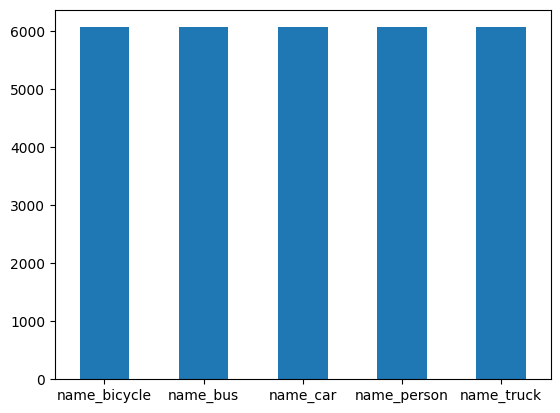

In [5]:
#plot the label distribution of the entire dataframe before splitting
encoded_columns = ["name_bicycle", "name_bus", "name_car", "name_person", "name_truck"]
sum_labels = df[encoded_columns].sum()
sum_labels.plot.bar(x = "labels", y = "count", rot = 0)

In [6]:
#split into train and val:
df_train, df_val = train_test_split(
    df,
    test_size = .15,
    shuffle = True,
    stratify = df[encoded_columns],
    random_state = 42
)

<Axes: >

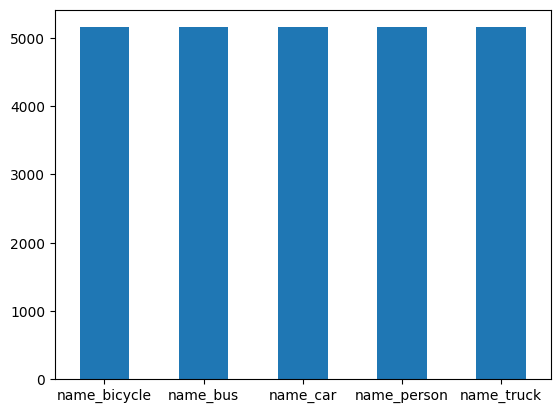

In [7]:
sum_labels_train = df_train[encoded_columns].sum()
sum_labels_train.plot.bar(x = "labels", y = "count", rot = 0)

<Axes: >

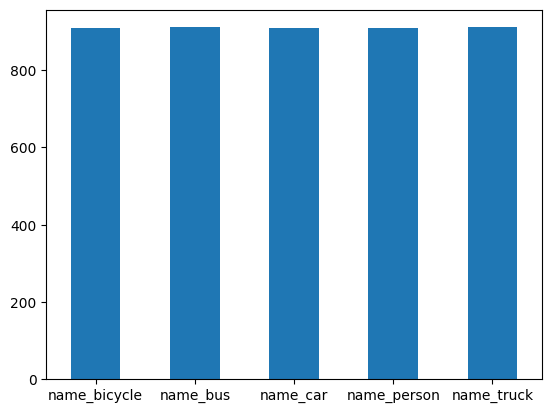

In [8]:
sum_labels_val = df_val[encoded_columns].sum()
sum_labels_val.plot.bar(x = "labels", y = "count", rot = 0)

In [9]:
#Image transformations

val_augmentations = transforms.Compose([
    transforms.Resize((128, 128))
])

test_augmentations = transforms.Compose([
    transforms.Resize((128, 128))
])

train_augmentations = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.4, 0.4, 0.2, 0.1),
])

required_augmentations = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


#encoded_column_names = ["encoder__name_bus", "encoder__name_car", "encoder__name_person", "encoder__name_truck"]

Augmentation that gets applied to the image before it is passed into the CNN

In [10]:
#Dataset class
class CocoVehicleDataset(Dataset):
    __slots__ = "dataframe", "root_directory", "required_augmentations", "set_agumentations", "labels"
    
    def __init__(self, dataframe, root_directory, required_augmentations, set_augmentations = None):
        """
        Initializes csv file
        """
        self.coco_frame = dataframe
        self.root_directory = root_directory
        self.required_augmentations = required_augmentations
        self.set_augmentations = set_augmentations
        
        self.labels = torch.tensor(self.coco_frame.iloc[:, 0:5].values, dtype=torch.float32)


    def __len__(self):
        return len(self.coco_frame)

    def __getitem__(self, row_index):
        """
        This gets the specific image sample corresponding to the 
        row of the csv file
        """
        if torch.is_tensor(row_index):
            row_index = row_index.tolist()
        
        #the full path to the image
        img_path = os.path.join(self.root_directory, self.coco_frame.iloc[row_index, 14])
                     
        image = decode_image(img_path)
        image = image.float() / 255.0

        #print(f"Dtype: {image.dtype}")
        #print(f"Shape: {image.shape}")
        #print(f"Min:   {image.min().item():.4f}")
        #print(f"Max:   {image.max().item():.4f}")
 
        label = self.labels[row_index]

        #apply these image augmentations only on training set
        if self.set_augmentations is not None:
            image = self.set_augmentations(image)

        #normalization for both train and val sets
        image = self.required_augmentations(image)
        
        #return tuple that contains the image and its corresponding label(category), label is converted to tensor
        return image, torch.tensor(label, dtype = torch.float)
        

Dataset class holds and extracts CSV rows and augmented images corresponding to the rows. 

In [11]:
#initialize datasets and dataloaders for trianing and validation set
training_coco_set = CocoVehicleDataset(df_train, images_path, required_augmentations, train_augmentations)
validation_coco_set = CocoVehicleDataset(df_val, images_path, required_augmentations, val_augmentations)
test_coco_set = CocoVehicleDataset(df_test, images_test_path, required_augmentations, test_augmentations)

training_data_loader = DataLoader(training_coco_set, batch_size = 32, shuffle = True)
validation_data_loader = DataLoader(validation_coco_set, batch_size = 32, shuffle = False)
test_data_loader = DataLoader(test_coco_set, batch_size = 32, shuffle = False)

/tmp/ipykernel_56/2674496025.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return image, torch.tensor(label, dtype = torch.float)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7202835..2.1758387].


Features batch shape: torch.Size([32, 3, 128, 128])
Labels batch shape: torch.Size([32, 5])


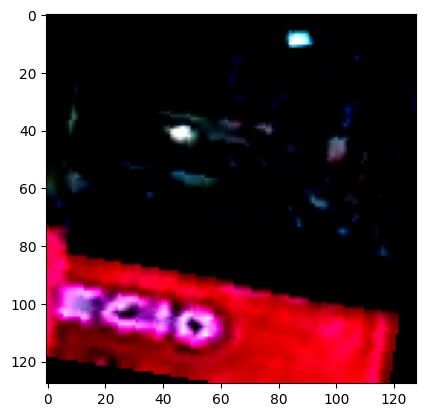

Label: tensor([0., 1., 0., 0., 0.])


In [58]:
#test train dataloader
train_images, train_labels = next(iter(training_data_loader))
print("Features batch shape: " + str(train_images.size()))
print("Labels batch shape: " + str(train_labels.size()))

img = train_images[0].squeeze()
label = train_labels[0]

img_to_plot = img.permute(1, 2, 0)
plt.imshow(img_to_plot)
plt.show()
print("Label: " + str(label))

/tmp/ipykernel_55/2674496025.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return image, torch.tensor(label, dtype = torch.float)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6428864..2.64].


torch.Size([32, 3, 128, 128])
torch.Size([32, 5])


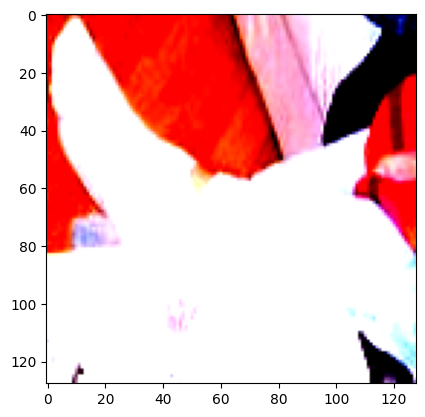

Label tensor([0., 0., 0., 1., 0.])


In [12]:
#test validation set dataloader
val_images, val_labels = next(iter(validation_data_loader))
print(val_images.size())
print(val_labels.size())

img = val_images[0].squeeze()
label = val_labels[0]
img_to_plot = img.permute(1, 2, 0)
plt.imshow(img_to_plot)
plt.show()
print("Label " + str(label))

/tmp/ipykernel_55/2674496025.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return image, torch.tensor(label, dtype = torch.float)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.602712].


torch.Size([32, 3, 128, 128])
torch.Size([32, 5])


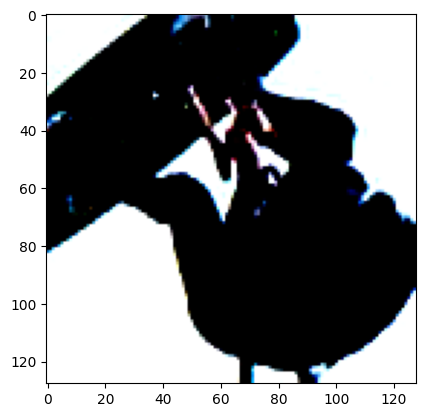

Label tensor([0., 0., 0., 1., 0.])


In [10]:
#test the test set dataloader
test_images, test_labels = next(iter(test_data_loader))
print(test_images.size())
print(test_labels.size())

img = test_images[0].squeeze()
label = test_labels[0]
img_to_plot = img.permute(1, 2, 0)
plt.imshow(img_to_plot)
plt.show()
print("Label " + str(label))

In [13]:
#CNN model
class CNN(nn.Module):
    
    def __init__(self, in_channels, num_classes):
        """
        Initialize convolutional layers, pooling layers and linear layer
        """
        super(CNN, self).__init__()
        self.conv_layer_1 = nn.Conv2d(in_channels = in_channels, out_channels = 32, kernel_size = 3, padding = 1)
        self.conv_layer_2 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, padding = 1)
        self.conv_layer_3 = nn.Conv2d(in_channels = 64, out_channels = 128, kernel_size = 3, padding = 1)
        self.conv_layer_4 = nn.Conv2d(in_channels = 128, out_channels = 128, kernel_size = 3, padding = 1)
        
        self.pooling_layer = nn.MaxPool2d(kernel_size = 2, stride = 2)
        
        self.hidden_layer_1 = nn.Linear(128 * 8 * 8, 512)
        self.dropout_1 = nn.Dropout(p = 0.5)
        self.last_layer = nn.Linear(512, num_classes)

    def forward(self, x):
        """
        Defines the architecture of a forward pass. 
        This can change depending on validation set metrics.
        3 convolutional layers, 3 pooling layers, 1 hidden layer.
        """
        x = activation.relu(self.conv_layer_1(x))
        x = self.pooling_layer(x)
        x = activation.relu(self.conv_layer_2(x))
        x = self.pooling_layer(x)
        x = activation.relu(self.conv_layer_3(x))
        x = self.pooling_layer(x)
        x = activation.relu(self.conv_layer_4(x))
        x = self.pooling_layer(x)
        
        #flatten and pass into dense layer
        x = x.reshape(x.shape[0], -1)
        x = activation.relu(self.hidden_layer_1(x))
        x = self.dropout_1(x)
        x = self.last_layer(x)
        
        return x

In [61]:
#initialize cnn model
cnn_model = CNN(in_channels = 3, num_classes = 5)
print(cnn_model)

CNN(
  (conv_layer_1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_layer_2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_layer_3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_layer_4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling_layer): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (hidden_layer_1): Linear(in_features=8192, out_features=512, bias=True)
  (dropout_1): Dropout(p=0.5, inplace=False)
  (last_layer): Linear(in_features=512, out_features=5, bias=True)
)


In [29]:
#Initialice trained_cnn_model: ONLY USE THIS CELL FOR TEST SET

# 1. Initialize the architecture (must be the 128x128 version)
#device = torch.device("cpu")
test_model = CNN(in_channels = 3, num_classes = 5)

# 3. Load the weights from the trained CNN 
test_model.load_state_dict(torch.load(model_path, map_location=device))

test_model.to(device)
test_model.eval()

print("Model loaded successfully and set to evaluation mode!")

Model loaded successfully and set to evaluation mode!


In [31]:
#RUN TEST MODEL
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_data_loader:
        images = images.to(device)
        
        # Get model predictions
        outputs = test_model(images)
        _, predicted = torch.max(outputs, 1)
        
        # IF labels are one-hot (e.g., [0, 1, 0...]), find the index of the '1'
        if len(labels.shape) > 1: 
            actual_labels = torch.argmax(labels, dim=1)
        else:
            actual_labels = labels

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(actual_labels.cpu().numpy())

/tmp/ipykernel_55/2674496025.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return image, torch.tensor(label, dtype = torch.float)


              precision    recall  f1-score   support

name_bicycle       0.22      0.81      0.35       316
    name_bus       0.37      0.78      0.50       285
    name_car       0.65      0.58      0.62      1932
 name_person       0.98      0.84      0.90     11004
  name_truck       0.27      0.65      0.38       415

    accuracy                           0.80     13952
   macro avg       0.50      0.73      0.55     13952
weighted avg       0.88      0.80      0.83     13952



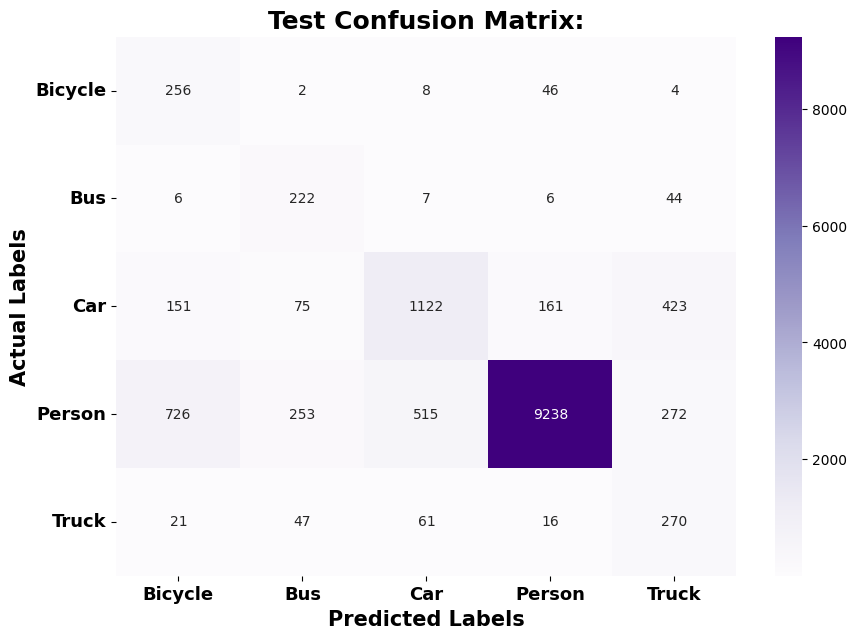

In [32]:
vehicle_names = ['name_bicycle', 'name_bus', 'name_car', 'name_person', 'name_truck']

display_names = ['Bicycle', 'Bus', 'Car', 'Person', 'Truck']

print(classification_report(all_labels, all_preds, target_names=vehicle_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=display_names, 
            yticklabels=display_names)

# 2. Adjusting the X-axis (Predicted) tick labels
plt.xticks(fontsize=13, fontweight='bold', rotation=0) 

# 3. Adjusting the Y-axis (Actual) tick labels
# rotation=0 keeps them horizontal so they are easier to read
plt.yticks(fontsize=13, fontweight='bold', rotation=0)

plt.xlabel('Predicted Labels', fontsize=15, fontweight='bold')
plt.ylabel('Actual Labels', fontsize=15, fontweight='bold')

plt.title('Test Confusion Matrix:', fontsize=18, fontweight="bold")
plt.show()

In [14]:
#Initialice trained_cnn_model: ONLY USE THIS CELL FOR VALIDATION SET

# 1. Initialize the architecture (must be the 128x128 version)

#device = torch.device("cpu")
validation_model = CNN(in_channels = 3, num_classes = 5)

# 3. Load the weights from the trained CNN 
validation_model.load_state_dict(torch.load(model_path, map_location=device))

validation_model.to(device)
validation_model.eval()

print("Model loaded successfully and set to evaluation mode!")

Model loaded successfully and set to evaluation mode!


In [17]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in validation_data_loader:
        images = images.to(device)
        
        # Get model predictions
        outputs = validation_model(images)
        _, predicted = torch.max(outputs, 1)
        
        # IF labels are one-hot (e.g., [0, 1, 0...]), find the index of the '1'
        if len(labels.shape) > 1: 
            actual_labels = torch.argmax(labels, dim=1)
        else:
            actual_labels = labels

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(actual_labels.cpu().numpy())

/tmp/ipykernel_55/2674496025.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return image, torch.tensor(label, dtype = torch.float)


              precision    recall  f1-score   support

name_bicycle       0.79      0.84      0.82       910
    name_bus       0.79      0.78      0.79       911
    name_car       0.67      0.55      0.60       910
 name_person       0.76      0.82      0.79       910
  name_truck       0.63      0.66      0.65       911

    accuracy                           0.73      4552
   macro avg       0.73      0.73      0.73      4552
weighted avg       0.73      0.73      0.73      4552



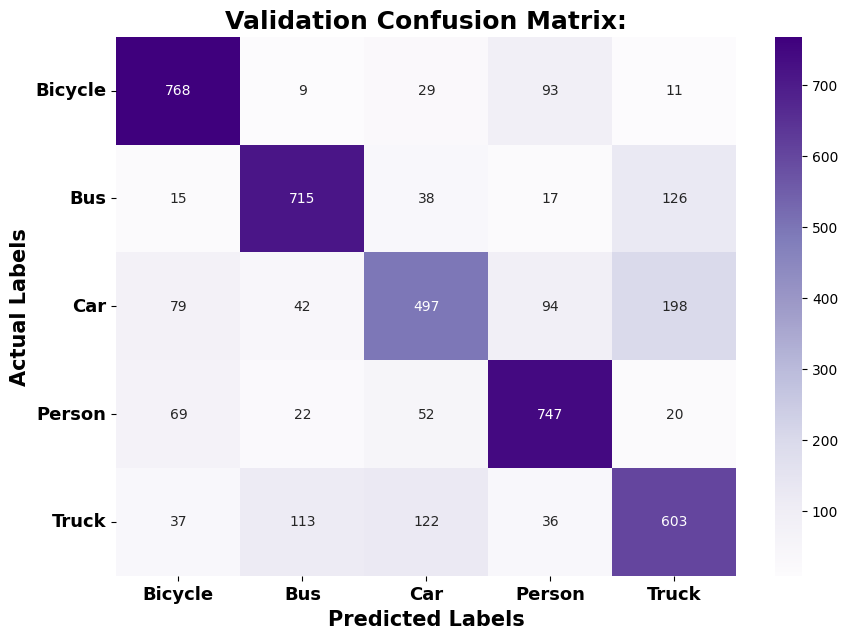

In [28]:
vehicle_names = ['name_bicycle', 'name_bus', 'name_car', 'name_person', 'name_truck']

display_names = ['Bicycle', 'Bus', 'Car', 'Person', 'Truck']

print(classification_report(all_labels, all_preds, target_names=vehicle_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=display_names, 
            yticklabels=display_names)

# 2. Adjusting the X-axis (Predicted) tick labels
plt.xticks(fontsize=13, fontweight='bold', rotation=0) 

# 3. Adjusting the Y-axis (Actual) tick labels
# rotation=0 keeps them horizontal so they are easier to read
plt.yticks(fontsize=13, fontweight='bold', rotation=0)

plt.xlabel('Predicted Labels', fontsize=15, fontweight='bold')
plt.ylabel('Actual Labels', fontsize=15, fontweight='bold')

plt.title('Validation Confusion Matrix:', fontsize=18, fontweight="bold")
plt.show()

In [ ]:
all_preds = []
all_labels = []

with torch.no_grad():
        for batch, (val_data, val_targets) in enumerate(validation_data_loader):
            val_data = val_data.to(device)
            val_targets = val_targets.to(device)
            
            val_predictions = cnn_model(val_data)
            val_loss = e_loss(val_predictions, val_targets)
            accumulated_loss += val_loss.item()
            
            val_targets_indices = torch.argmax(val_targets, dim = 1)
            _, val_predicted_classes = torch.max(val_predictions, 1)
            
            val_total_samples += val_targets_indices.size(0)
            val_correct += (val_predicted_classes == val_targets_indices).sum().item()

            val_recall.update(val_predicted_classes, val_targets_indices)
            val_spec.update(val_predicted_classes, val_targets_indices)
            val_prec.update(val_predicted_classes, val_targets_indices)

            all_preds.extend(predicted.numpy())
            all_labels.extend(actual_labels.numpy())

In [16]:
vehicle_names = ['name_bicycle', 'name_bus', 'name_car', 'name_person', 'name_truck']
print(classification_report(all_labels, all_preds, target_names=vehicle_names))

              precision    recall  f1-score   support

name_bicycle       0.79      0.84      0.82       910
    name_bus       0.79      0.78      0.79       911
    name_car       0.67      0.55      0.60       910
 name_person       0.76      0.82      0.79       910
  name_truck       0.63      0.66      0.65       911

    accuracy                           0.73      4552
   macro avg       0.73      0.73      0.73      4552
weighted avg       0.73      0.73      0.73      4552



In [62]:

e_loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr = 0.0003, weight_decay = .0001)

num_epochs = 20

cnn_model.to(device)
train_recall = MulticlassRecall(num_classes=5, average='macro').to(device)
val_recall = MulticlassRecall(num_classes=5, average='macro').to(device)

train_spec = MulticlassSpecificity(num_classes=5, average='macro').to(device)
val_spec = MulticlassSpecificity(num_classes=5, average='macro').to(device)

train_prec = MulticlassPrecision(num_classes=5, average='macro').to(device)
val_prec = MulticlassPrecision(num_classes=5, average='macro').to(device)

history = {
    'train_acc': [], 'val_acc': [],
    'train_prec': [], 'val_prec': [],
    'train_rec': [], 'val_rec': [],
    'train_spec': [], 'val_spec': []
}
best_val_loss = float('inf')



In [67]:
#for g in optimizer.param_groups:
    #g['lr'] = 0.0003


current_lr = optimizer.param_groups[0]['lr']
print(f"The new learning rate is: {current_lr}")


for epoch in range(10):
    cnn_model.train()

    train_recall.reset()
    train_spec.reset()
    train_prec.reset()
    
    print("StartingEpoch: " + str(epoch))
    total_samples = 0
    correct_samples = 0
    accumulated_train_loss = 0

    #get batch of 32 images and their corresponding labels from data_loader
    for batch, (data, targets) in enumerate(training_data_loader):

        data = data.to(device)
        targets = targets.to(device)
        #run cnn model on images
        predictions = cnn_model(data)

        #calculate loss
        loss = e_loss(predictions, targets)
        accumulated_train_loss += loss.item()
        
        optimizer.zero_grad()
        
        #backpropogation
        loss.backward()
        optimizer.step()

        #convert to 1d tensor to compare to predicted labels
        targets_indices = torch.argmax(targets, dim=1) 
        _, predicted_classes = torch.max(predictions, 1)
        
        # total samples for training set
        total_samples += targets_indices.size(0)

        #print(targets.shape)
        #print(predicted_classes.shape)
        #print(targets.shape)
        #print(predicted_classes.shape)
        correct_samples += (predicted_classes == targets_indices).sum().item()

        train_recall.update(predicted_classes, targets_indices)
        train_spec.update(predicted_classes, targets_indices)
        train_prec.update(predicted_classes, targets_indices)

    
    #set model to evaluate mode for validation set
    cnn_model.eval()
    val_total_samples = 0
    val_correct = 0
    accumulated_loss = 0.0

    val_recall.reset()
    val_spec.reset()
    val_prec.reset()
    
    with torch.no_grad():
        for batch, (val_data, val_targets) in enumerate(validation_data_loader):
            val_data = val_data.to(device)
            val_targets = val_targets.to(device)
            
            val_predictions = cnn_model(val_data)
            val_loss = e_loss(val_predictions, val_targets)
            accumulated_loss += val_loss.item()
            
            val_targets_indices = torch.argmax(val_targets, dim = 1)
            _, val_predicted_classes = torch.max(val_predictions, 1)
            
            val_total_samples += val_targets_indices.size(0)
            val_correct += (val_predicted_classes == val_targets_indices).sum().item()

            val_recall.update(val_predicted_classes, val_targets_indices)
            val_spec.update(val_predicted_classes, val_targets_indices)
            val_prec.update(val_predicted_classes, val_targets_indices)

            all_val_preds.extend(predicted.numpy())
            all_val_labels.extend(actual_labels.numpy())

        

    
    train_accuracy = round(100 * (correct_samples / total_samples), 2)
    train_average_loss = round(accumulated_train_loss / len(training_data_loader), 2)
    train_recall_value = round(100 * (train_recall.compute().item()), 2)
    train_spec_value = round(100 * (train_spec.compute().item()), 2)
    train_prec_value = round(100 * (train_prec.compute().item()), 2)
    print("train loss: " + str(train_average_loss) + ", train accuracy: " + str(train_accuracy) + "%, train recall: " + str(train_recall_value) + "%, train spec: " + str(train_spec_value) + "%, train prec: " + str(train_prec_value) + "%")

    val_accuracy = round(100 * (val_correct / val_total_samples), 2)
    val_average_loss = round(accumulated_loss / len(validation_data_loader), 2)
    val_recall_value = round(100 * (val_recall.compute().item()), 2)
    val_spec_value = round(100 * (val_spec.compute().item()), 2)
    val_prec_value = round(100 * (val_prec.compute().item()), 2)
    print("val loss: " + str(val_average_loss) + ", val accuracy: " + str(val_accuracy) + "%, val recall: " + str(val_recall_value) + "%, val spec: " + str(val_spec_value) + "%, val prec: " + str(val_prec_value) + "%" + "\n")

    history['train_acc'].append(train_accuracy)
    history['train_prec'].append(train_prec_value)
    history['train_rec'].append(train_recall_value)
    history['train_spec'].append(train_spec_value)
    
    history['val_acc'].append(val_accuracy)
    history['val_prec'].append(val_prec_value)
    history['val_rec'].append(val_recall_value)
    history['val_spec'].append(val_spec_value)

    if val_average_loss < best_val_loss:
        print(f"New Record! Loss decreased from {best_val_loss:.4f} to {val_average_loss:.4f}. Saving model...")
        best_val_loss = val_average_loss
        torch.save(cnn_model.state_dict(), 'best_model.pth')


The new learning rate is: 0.0003
StartingEpoch: 0


/tmp/ipykernel_56/2674496025.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return image, torch.tensor(label, dtype = torch.float)


train loss: 0.54, train accuracy: 79.27%, train recall: 79.27%, train spec: 94.82%, train prec: 79.28%
val loss: 0.71, val accuracy: 74.01%, val recall: 74.01%, val spec: 93.5%, val prec: 74.29%

StartingEpoch: 1
train loss: 0.53, train accuracy: 79.87%, train recall: 79.87%, train spec: 94.97%, train prec: 79.95%
val loss: 0.71, val accuracy: 73.57%, val recall: 73.57%, val spec: 93.39%, val prec: 73.94%

StartingEpoch: 2
train loss: 0.51, train accuracy: 80.45%, train recall: 80.45%, train spec: 95.11%, train prec: 80.51%
val loss: 0.78, val accuracy: 73.4%, val recall: 73.4%, val spec: 93.35%, val prec: 73.7%

StartingEpoch: 3
train loss: 0.51, train accuracy: 80.69%, train recall: 80.69%, train spec: 95.17%, train prec: 80.71%
val loss: 0.71, val accuracy: 73.22%, val recall: 73.22%, val spec: 93.31%, val prec: 73.28%

StartingEpoch: 4
train loss: 0.5, train accuracy: 80.97%, train recall: 80.97%, train spec: 95.24%, train prec: 81.03%
val loss: 0.79, val accuracy: 72.47%, val reca

Data points found: 35
First data point: 51.27
Type: <class 'float'>


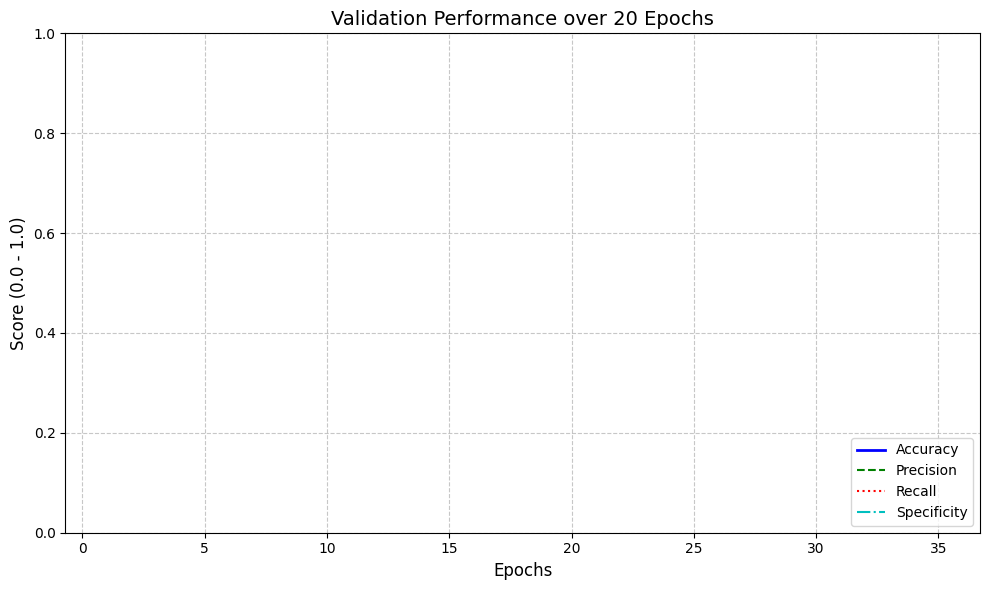

Graph saved as training_performance.png


<Figure size 640x480 with 0 Axes>

In [72]:
print(f"Data points found: {len(history['val_acc'])}")

if len(history['val_acc']) > 0:
    print(f"First data point: {history['val_acc'][0]}")
    print(f"Type: {type(history['val_acc'][0])}")

#plot validation metrics after all epochs
def plot_metrics(history):
    epochs = range(1, len(history['val_acc']) + 1)
    
    plt.figure(figsize=(10, 6))
    
    # Plotting the 4 key validation metrics
    plt.plot(epochs, history['val_acc'], 'b-', label='Accuracy', linewidth=2)
    plt.plot(epochs, history['val_prec'], 'g--', label='Precision')
    plt.plot(epochs, history['val_rec'], 'r:', label='Recall')
    plt.plot(epochs, history['val_spec'], 'c-.', label='Specificity')
    
    plt.title('Validation Performance over 20 Epochs', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ylim(0, 1.0) # Keeps the scale consistent
    
    plt.tight_layout()
    plt.show()
    plt.savefig('training_performance.png')
    print("Graph saved as training_performance.png")

plot_metrics(history)

In [65]:
#model_path = "cnn_model_64x64_69percent.pth"

# Save the weights
#torch.save(cnn_model.state_dict(), model_path)
#print(f"Model weights saved to {model_path}")